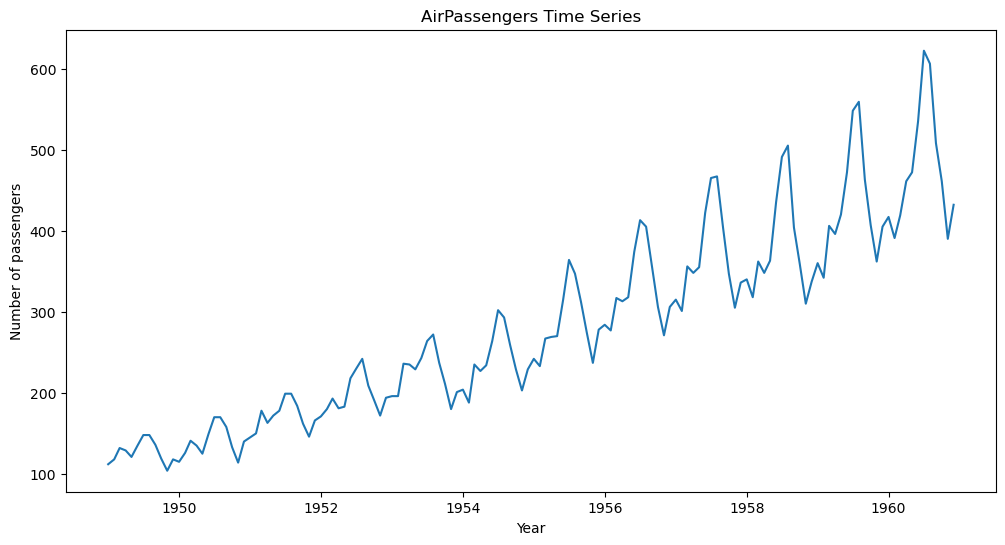

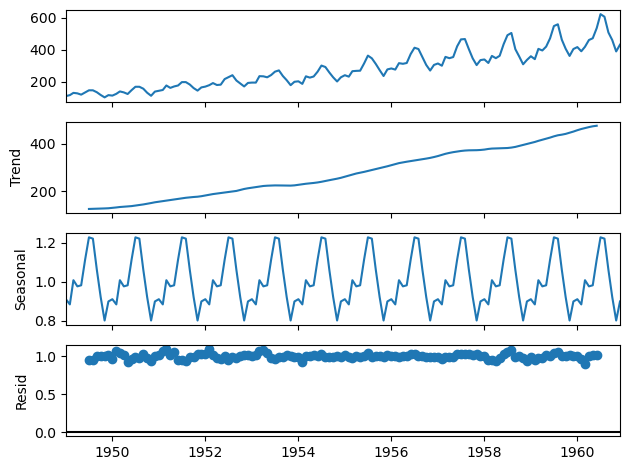

In [12]:
### Import Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings('ignore')

## Load Dataset
data = pd.read_csv("AirPassengers.csv")

## Convert Month column to datetime FIRST
data['Month'] = pd.to_datetime(data['Month'])

## Set Month as index
data.set_index('Month', inplace=True)

## ploting orignal time Series
plt.figure(figsize=(12,6))
plt.title("AirPassengers Time Series")
plt.plot(data['#Passengers'])
plt.xlabel("Year")
plt.ylabel("Number of passengers")
plt.legend
plt.show


## Decompose the time series
decomposition = seasonal_decompose(data, model="multiplicative", period=12)

## Plot decomposition
decomposition.plot()
plt.show()

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   #Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [14]:
plt.savefig("airpassengers_timeseries.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

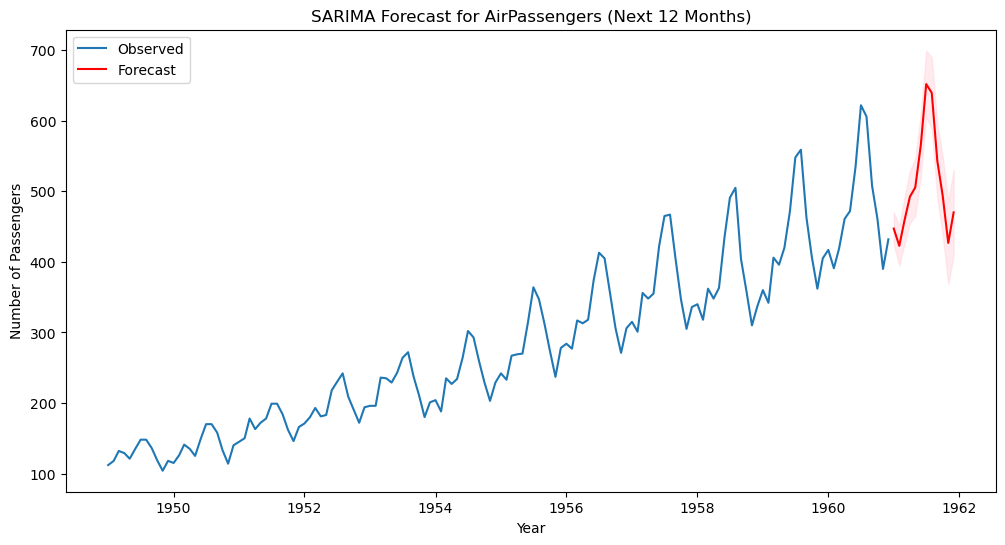

In [15]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# Load AirPassengers dataset
data = pd.read_csv("AirPassengers.csv")

# Convert Month to datetime and set as index
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)

# Define the time series
ts = data['#Passengers']

# Train SARIMA model
# SARIMA(p,d,q)(P,D,Q,s)
model = SARIMAX(
    ts,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

# Forecast next 12 months
forecast = results.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Create forecast index
forecast_index = pd.date_range(
    start=ts.index[-1] + pd.offsets.MonthEnd(1),
    periods=12,
    freq='M'
)

forecast_mean.index = forecast_index
forecast_ci.index = forecast_index

# Plot original data and forecast
plt.figure(figsize=(12,6))
plt.plot(ts, label='Observed')
plt.plot(forecast_mean, label='Forecast', color='red')
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color='pink',
    alpha=0.3
)
plt.title("SARIMA Forecast for AirPassengers (Next 12 Months)")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()


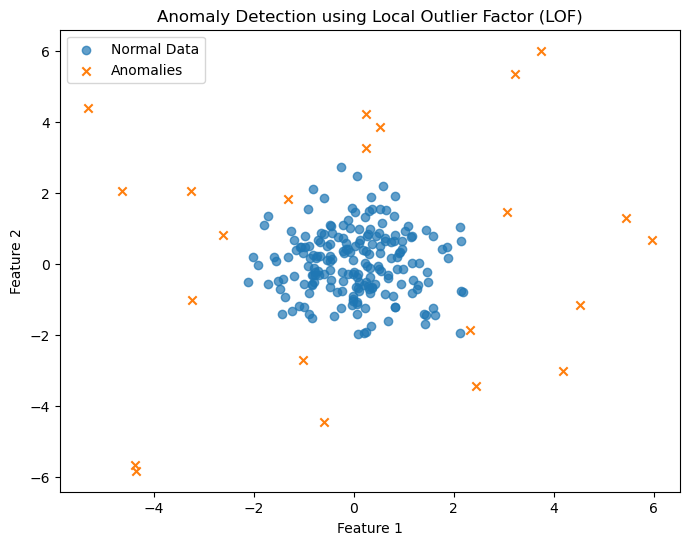

In [17]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# Create a numerical dataset (2D for easy visualization)
np.random.seed(42)
X_normal = np.random.normal(loc=0, scale=1, size=(200, 2))
X_outliers = np.random.uniform(low=-6, high=6, size=(20, 2))

# Combine normal data and outliers
X = np.vstack((X_normal, X_outliers))

# Apply Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred = lof.fit_predict(X)

# Separate normal points and anomalies
normal_points = X[y_pred == 1]
anomalies = X[y_pred == -1]

# Plot the results
plt.figure(figsize=(8,6))
plt.scatter(normal_points[:, 0], normal_points[:, 1], label="Normal Data", alpha=0.7)
plt.scatter(anomalies[:, 0], anomalies[:, 1], label="Anomalies", marker='x')
plt.title("Anomaly Detection using Local Outlier Factor (LOF)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()
